In [1]:
# Imports

import os
from dotenv import load_dotenv
from typing import TypedDict

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END

from sentence_transformers import CrossEncoder

In [2]:
# Load Environment
load_dotenv()

True

In [3]:
# Embeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Load Constitution Vector DB

DB_PATH = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\vector_database"

constitution_db = Chroma(
    persist_directory=DB_PATH,
    embedding_function=embeddings,
    collection_name="legal_knowledge"
)

print("Total constitution chunks:", constitution_db._collection.count())

Total constitution chunks: 787


In [5]:
# Document Chunking Function

import re
from langchain_core.documents import Document

def split_documents(docs, embeddings, debug=False):
    # 1. CLEANING: Remove Non-ASCII noise and horizontal footers
    cleaned_docs = []
    for doc in docs:
        text = "".join(i for i in doc.page_content if ord(i) < 128)
        text = re.split(r'_{2,}', text)[0].strip()
        doc.page_content = text
        cleaned_docs.append(doc)

    # 2. STRUCTURAL SPLITTING: Keep headers at the start of chunks
    structure_splitter = RecursiveCharacterTextSplitter(
        chunk_size=2000,
        chunk_overlap=300,
        separators=[
            r"\n\s*Article\s+\d+", 
            r"\n\s*Section\s+\d+",
            r"\n\s*JUDGMENT",
            "\n\n",
            "\n"
        ],
        keep_separator=True,
        is_separator_regex=True
    )
    
    initial_chunks = structure_splitter.split_documents(cleaned_docs)
    
    # 3. HYBRID TAGGING: Prepend section references to every chunk
    hybrid_docs = []
    for chunk in initial_chunks:
        # Extract the first line as the reference (e.g., "Article 21")
        lines = chunk.page_content.split('\n')
        page_reference = lines[0][:60].strip() if lines else "General Provision"
        
        # Prepend reference so it is "unbreakable" during retrieval
        tagged_content = f"LAW_SECTION_REFERENCE: {page_reference}\n\nCONTENT: {chunk.page_content}"
        
        hybrid_docs.append(Document(
            page_content=tagged_content,
            metadata=chunk.metadata 
        ))

    # 4. FINAL RECURSIVE SPLIT: Ensure chunks fit LLM context windows
    final_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500,
        chunk_overlap=300
    )

    return final_splitter.split_documents(hybrid_docs)

In [6]:
# Load Uploaded Document function

from langchain_community.vectorstores import Chroma

def load_uploaded_document(file_path):

    loader = PyPDFLoader(file_path)
    docs = loader.load()

    chunks = split_documents(docs, embeddings)

    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name="uploaded_doc"
    )

    print("Uploaded document indexed:", len(chunks))

    return vector_store

In [7]:
# Legal Knowledge Retrieval function

def retrieve_legal_docs(query, k=5):

    docs = constitution_db.similarity_search(
        f"{query} legal principle",
        k=k
    )

    return docs

In [8]:
# Graph State

from typing import TypedDict, Optional, Any

# Update your cell where LegalState is defined
class LegalState(TypedDict):
    question: str
    strategy: str
    plan: str           # ADDED: This matches the strategist_agent return key
    queries: list[str] 
    legal_context: str
    document_context: str
    document_db: Any
    answer: str
    critic_decision: str 
    retry_count: int

In [9]:
# Cross Encoder Reranker

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# Uploaded Document Retrieval function

def retrieve_document_docs(state: LegalState, k=15):

    vector_store = state.get("document_db")

    if vector_store is None:
        return []

    query = state["question"]

    docs = vector_store.similarity_search(query, k=k)

    pairs = [[query, d.page_content] for d in docs]

    scores = reranker.predict(pairs)

    ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)

    return [doc for doc,_ in ranked[:10]]

In [11]:
# Validation Check
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY not found. Please set it in your .env file or environment.")
else:
    print("Groq API Key successfully loaded.")

Groq API Key successfully loaded.


In [12]:
# LLM 

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [13]:
# Strategist Agent

def strategist_agent(state: LegalState):
    question = state["question"]

    prompt = f"""
You are a legal strategist and search expert. Analyze the question and provide:
1. Strategy: <legal | document | both>
2. Search Queries: Generate 3 specific search queries for retrieval.

Example: If the question is about 'Right to Privacy', queries should be:
- "Fundamental right to privacy Indian Constitution"
- "Justice K.S. Puttaswamy vs Union of India judgment summary"
- "Article 21 and privacy protection"

Question: {question}
Respond strictly in this format:
Strategy: <strategy>
Queries:
- Query 1
- Query 2
- Query 3
"""
    response = llm.invoke(prompt).content
    
    # Extraction Logic
    strategy = "legal"
    if "both" in response.lower(): strategy = "both"
    elif "document" in response.lower(): strategy = "document"
    
    # Extract queries into a list
    queries = [q.strip("- ") for q in response.split("Queries:")[1].strip().split("\n")] if "Queries:" in response else [question]

    return {
        "strategy": strategy,
        "plan": response,
        "queries": queries # New field for State
    }

In [14]:
# Legal Research Agent

def legal_research_agent(state: LegalState):
    # Iterate through expanded queries for better coverage
    all_docs = []
    queries = state.get("queries", [state["question"]])
    
    for q in queries:
        # Increase k to 8 as suggested for broader context
        all_docs.extend(retrieve_legal_docs(q, k=8))
    
    # Remove duplicates based on content
    unique_docs = {d.page_content: d for d in all_docs}.values()
    context = "\n\n".join([d.page_content for d in unique_docs])

    return {"legal_context": context}

In [15]:
# Document Research Agent

def document_research_agent(state: LegalState):

    docs = retrieve_document_docs(state, k=20)

    if len(docs) == 0:
        return {"document_context": ""}

    context = "\n\n".join([d.page_content for d in docs])

    return {"document_context": context}

In [16]:
from sentence_transformers import CrossEncoder

# Initialize the CrossEncoder globally
# Using 'cross-encoder/ms-marco-MiniLM-L-6-v2' is a high-speed, 
# high-accuracy standard for reranking legal text.
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')


def advisor_agent(state: LegalState):
    import numpy as np # Ensure numpy is available for sorting
    
    # Combine both contexts
    legal_ctx = state.get('legal_context', '')
    doc_ctx = state.get('document_context', '')
    full_ctx = f"{legal_ctx}\n\n{doc_ctx}".strip()
    
    # Reranking Logic: Use the 'reranker' variable initialized in your notebook
    if full_ctx and 'reranker' in globals():
        chunks = [c for c in full_ctx.split("\n\n") if c.strip()]
        pairs = [[state["question"], chunk] for chunk in chunks]
        scores = reranker.predict(pairs) # Corrected to 'reranker'
        
        # Take top 8 most relevant chunks
        ranked_indices = np.argsort(scores)[::-1][:8]
        refined_context = "\n\n".join([chunks[i] for i in ranked_indices])
    else:
        refined_context = full_ctx if full_ctx else "No context found."

    prompt = f"""You are an expert Indian legal advisor. Analyze the case:
    1. List legal principles found in the Context.
    2. Identify relevant facts from the Context.
    3. Apply the law to the facts to answer the question.

    CONTEXT: {refined_context}
    QUESTION: {state['question']}
    
    If the context is insufficient, begin your response with: CRITIC_FAIL
    """
    
    response = llm.invoke(prompt)
    return {"answer": response.content}

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
# Update your critic_agent function
# THE NODE: Only updates the state
def critic_agent(state: LegalState):
    answer = state.get("answer", "").lower()
    retries = state.get("retry_count", 0)
    
    # If LLM failed or explicitly asked for more info
    if ("information not available" in answer or "critic_fail" in answer) and retries < 2:
        return {"critic_decision": "retry", "retry_count": retries + 1}
    
    return {"critic_decision": "final"}

# THE ROUTER: Only handles the logic of where to go
def route_after_critic(state: LegalState):
    return state.get("critic_decision", "final")

In [18]:
def route_research(state: LegalState):
    strategy = state.get("strategy", "both")
    
    if strategy == "legal":
        return ["legal_research"]
    elif strategy == "document":
        return ["document_research"]
    else:
        # Returns a list, triggering parallel execution of both spokes
        return ["legal_research", "document_research"]

In [19]:
workflow = StateGraph(LegalState)

workflow.add_node("strategist", strategist_agent)
workflow.add_node("legal_research", legal_research_agent)
workflow.add_node("document_research", document_research_agent)
workflow.add_node("advisor", advisor_agent)
workflow.add_node("critic", critic_agent)

workflow.set_entry_point("strategist")

# Updated for parallel "Fan-out"
workflow.add_conditional_edges(
    "strategist", 
    route_research, 
    {"legal_research": "legal_research", "document_research": "document_research"}
)

workflow.add_edge("legal_research", "advisor")
workflow.add_edge("document_research", "advisor")
workflow.add_edge("advisor", "critic")

# Updated for fixed "Critic" routing
workflow.add_conditional_edges(
    "critic",
    route_after_critic, 
    {"retry": "strategist", "final": END}
)

legal_graph = workflow.compile()

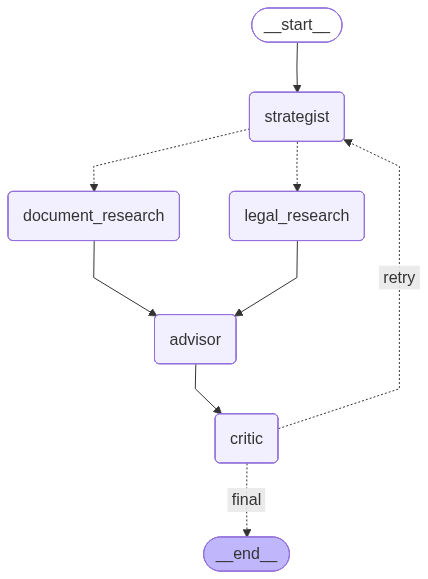

In [20]:
from IPython.display import Image, display

display(Image(legal_graph.get_graph().draw_mermaid_png()))

In [21]:
# RAG Main Agent Function

def legal_agentic_rag(question, uploaded_file=None):

    vector_store = None

    if uploaded_file is not None:
        vector_store = load_uploaded_document(uploaded_file)

    result = legal_graph.invoke({
        "question": question,
        "document_db": vector_store
    })

    return result["answer"]

In [22]:
print(
    legal_agentic_rag(
        "If a state law conflicts with a central law in India, which one prevails?"
    )
)

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kbn58qpqfjgstzyswyfty5g2` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 97605, Requested 3177. Please try again in 11m15.648s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
# File path of the uploaded case document
document_path = r"C:/Users/user/Desktop/RAG Projects/Legal RAG 1/data/Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF"

# Index the uploaded PDF and create a temporary vector store
uploaded_vector_store = load_uploaded_document(document_path)

# Test questions designed to validate document-specific retrieval
document_tests = [
    #("Who is the plaintiff in this case?", "Vandana Dhirani", "Validate extraction of key parties."),
    #("What is the CS DJ number of this suit?", "588/2021", "Verify retrieval of case identification details."),
    #("What was the outcome of the suit declared on 27.07.2023?", "Dismissed", "Confirm correct identification of the case result."),
    #("What does Issue No. 8 address?", "Interest", "Check recognition of specific legal issues."),
    #("Who presided as the judge at Saket Courts in this matter?", "Navjeet Budhiraja", "Verify judge name extraction."),
    #("Did the court grant recovery of arrears of rent?", "not found entitled", "Validate core judgment conclusions."),
    #("On which floor is property C-99 situated?", "4th Floor", "Check extraction of property-related details."),
    #("When was this suit officially instituted?", "31.08.2021", "Verify procedural timeline retrieval."),
    ("What justification did the defendant give for non-payment of rent in Issue 4?", "force majeure", "Check defense argument extraction (Covid / Force Majeure)."),
    #("Did the court order preparation of a decree sheet?", "Decree sheet be prepared", "Confirm recognition of final court directives.")
]

print("\n--- EXECUTING DOCUMENT RETRIEVAL TESTS ---\n")

for i, (question, expected_key, explanation) in enumerate(document_tests):

    # Run the RAG system with the uploaded document vector store
    answer = legal_agentic_rag(question, uploaded_file=document_path)

    # Initial evaluation check
    result_status = "PASS" if expected_key.lower() in answer.lower() else "FAIL"

    # Flexible checks for alternative phrasing or synonyms
    if result_status == "FAIL":
        if "dismiss" in answer.lower() and expected_key.lower() == "dismissed":
            result_status = "PASS (Synonym Match)"
        elif "not entitled" in answer.lower() and expected_key.lower() == "not found entitled":
            result_status = "PASS (Synonym Match)"
        elif "saket" in answer.lower() and expected_key.lower() == "navjeet budhiraja":
            result_status = "FAIL (Partial Match)"

    print(f"DOCUMENT TEST #{i+1}")
    print(f"Question: {question}")
    print(f"Model Answer: {answer.strip()}")
    print(f"Evaluation Result: {result_status} (Expected Key: {expected_key})")
    print(f"Test Purpose: {explanation}")
    print("-" * 60)

Uploaded document indexed: 111

--- EXECUTING DOCUMENT RETRIEVAL TESTS ---

Uploaded document indexed: 111


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kbn58qpqfjgstzyswyfty5g2` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99186, Requested 2750. Please try again in 27m52.704s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

# Benchmark set for evaluating general legal knowledge retrieval
# Each test includes:
# (question, expected_keyword, evaluation_note)

general_tests = [

    ("Under what circumstances can a Writ of Habeas Corpus be issued in India?",
     "Article 32",
     "Checks understanding of constitutional remedies and enforcement of fundamental rights."),

    ("What legal penalty exists for drunk driving under the Motor Vehicles Act?",
     "Section 185",
     "Verifies retrieval of specific statutory provisions."),

    ("Does the Constitution of India recognize the right to privacy?",
     "Puttaswamy",
     "Evaluates whether the system references the landmark privacy judgment."),

    ("How many members can the President nominate to the Rajya Sabha?",
     "12",
     "Tests factual constitutional knowledge regarding parliamentary composition."),

    ("Which article of the Constitution establishes the Finance Commission?",
     "Article 280",
     "Validates knowledge of constitutional administrative bodies."),

    ("Is a person allowed to be prosecuted twice for the same offence in India?",
     "Double Jeopardy",
     "Tests recognition of the Article 20(2) constitutional protection."),

    ("What is the minimum age required to become the Prime Minister of India?",
     "25",
     "Checks eligibility requirements linked to Lok Sabha membership."),

    ("Is the Right to Property still considered a Fundamental Right in India?",
     "300A",
     "Tests awareness of the 44th Constitutional Amendment change."),

    ("Which article of the Indian Constitution abolishes untouchability?",
     "Article 17",
     "Assesses understanding of core fundamental rights."),

    ("Can Fundamental Rights be suspended during a National Emergency?",
     "Article 359",
     "Evaluates knowledge of emergency provisions affecting rights.")
]

print("\n--- RUNNING GENERAL LEGAL KNOWLEDGE TESTS ---\n")


for i, (question, keyword, explanation) in enumerate(general_tests):

    response = legal_agentic_rag(question)

    answer = response.lower()

    # Primary keyword check
    status = "PASS" if keyword.lower() in answer else "FAIL"

    # Flexible checks for common variations
    if status == "FAIL":

        if "jeopardy" in answer and keyword.lower() == "double jeopardy":
            status = "PASS (Synonym)"

        elif "privacy" in answer and keyword.lower() == "puttaswamy":
            status = "PASS (Concept Match)"

        elif "property" in answer and keyword.lower() == "300a":
            status = "PASS (Concept Match)"

    print(f"TEST #{i+1}")
    print(f"Question: {question}")
    print(f"AI Answer: {response.strip()}")
    print(f"Result: {status} (Expected Keyword: {keyword})")
    print(f"Test Objective: {explanation}")
    print("-" * 60)